# SimPEG FDEM forward modeling of a vertical thin sheet — 10 Hz

**Objective.** Reproduce the IE reference (WSHEET20 / Python IE) forward responses at **10 Hz** as closely as the finite-volume fo ...

In [16]:
import gc
import os
import time
import warnings
import numpy as np
import pandas as pd

from discretize import TreeMesh
try:
    from simpeg import maps
    from simpeg.electromagnetics import frequency_domain as fdem
except ImportError:
    from SimPEG import maps
    from SimPEG.electromagnetics import frequency_domain as fdem
from scipy.constants import mu_0

warnings.filterwarnings("ignore", category=RuntimeWarning, module="geoana.*")

def _pick_solver():
    '''Import alone is not enough (Pardiso/Mumps import fine but fail at use when pydiso / python ...'''
    import scipy.sparse as sp
    A = sp.identity(4, format="csr") * 2.0
    try:
        import pymatsolver
        for name in ("Pardiso", "Mumps"):
            cls = getattr(pymatsolver, name, None)
            if cls is None:
                continue
            try:
                cls(A) * np.ones(4)
                return cls, f"pymatsolver.{name}", True
            except Exception:
                continue
    except ImportError:
        pass
    try:
        from simpeg.utils.solver_utils import SolverLU
    except ImportError:
        try:
            from simpeg import SolverLU
        except ImportError:
            from SimPEG import SolverLU
    return SolverLU, "SolverLU (scipy splu -- slow; install python-mumps or pydiso)", False

Solver, solver_name, fast_solver = _pick_solver()
print("Using solver:", solver_name)

Using solver: pymatsolver.Pardiso


In [17]:
frequency  = 10.0
sigma_host = 1.0 / 10.0

MU0_F  = 4.0e-7 * np.pi                     # exactly as in WSHEET20.F
EPS0_F = 8.85419e-12                        # exactly as in WSHEET20.F
eps_host = 10.0 * EPS0_F

sheet_cx, sheet_cy, sheet_cz = 500.0, 0.0, -100.0
sheet_strike_extent = 200.0
sheet_dip_extent    = 200.0
true_thickness      = 0.1

tau_conductive   = (1.0/1.0e-5 - sigma_host) * true_thickness
tau_zerocontrast = (1.0/10.000001 - sigma_host) * true_thickness
print(f"tau (scenario 1) = {tau_conductive:+.6e} S")
print(f"tau (scenario 2) = {tau_zerocontrast:+.6e} S")

src_loc = np.array([0.0, 0.0, 0.0])
moment  = 1.0
n_rx    = 201
rx_x    = np.linspace(0.0, 1000.0, n_rx)
rx_z    = 0.75
rx_loc  = np.column_stack([rx_x, np.zeros(n_rx), np.full(n_rx, rx_z)])

skin_depth = np.sqrt(2.0 / (2*np.pi*frequency * mu_0 * sigma_host))
print(f"skin depth {skin_depth:.2f} m; sheet at {500.0/skin_depth:.2f} skin depths")
print(f"induction number omega*mu0*tau*L ~ "
      f"{2*np.pi*frequency*mu_0*tau_conductive*200.0:.0f} (saturated inductive limit)")

IE_PEAK_SEC  = 1.5480e-9
IE_ZC_FLOOR  = 1.41e-20
IE_CROSSOVER = 500.0
IE_RE_IM     = 3.141

tau (scenario 1) = +9.999990e+03 S
tau (scenario 2) = -9.999999e-10 S
skin depth 503.29 m; sheet at 0.99 skin depths
induction number omega*mu0*tau*L ~ 158 (saturated inductive limit)


Analytic whole-space VMD field (e^{+i omega t}, same convention as SimPEG and WSHEET)

In [18]:
def analytic_H_zdipole(rx_xyz, freq, src=src_loc, sigma=sigma_host,
                       eps=eps_host, m=moment):
    om = 2*np.pi*freq
    k  = np.sqrt(-1j*om*MU0_F*(sigma + 1j*om*eps))
    if k.imag > 0:
        k = -k                               # decaying root: Im(k) < 0
    dx = rx_xyz[:, 0] - src[0]
    dy = rx_xyz[:, 1] - src[1]
    dz = rx_xyz[:, 2] - src[2]
    rr2 = dx**2 + dy**2 + dz**2
    rr  = np.sqrt(rr2)
    ikr = 1j*k*rr
    e   = np.exp(-ikr)
    fac_xy = 3.0*(1.0 + ikr) + ikr**2
    Hx = (m/(4*np.pi)) * e * dx*dz / rr**5 * fac_xy
    Hy = (m/(4*np.pi)) * e * dy*dz / rr**5 * fac_xy
    Hz = (m/(4*np.pi)) * e / rr**5 * (
        (3*dz**2 - rr2)*(1.0 + ikr) + (dz**2 - rr2)*ikr**2)
    return Hx, Hy, Hz

_H = analytic_H_zdipole(np.array([[30.0, 0.0, 0.75]]), 1e-6)
_r2 = 30.0**2 + 0.75**2
_Hz_static = (moment/(4*np.pi)) * (3*0.75**2 - _r2) / _r2**2.5
assert abs(_H[2][0] - _Hz_static)/abs(_Hz_static) < 1e-6
print("analytic dipole static-limit self-test passed")

analytic dipole static-limit self-test passed


Octree mesh, geometric refinement only (`refine_ball` / `refine_box`).

In [19]:
RESOLUTION_OVERRIDE = None
RESOLUTION = RESOLUTION_OVERRIDE or ("CONTAINER" if fast_solver else "SMOKE")

MESH_SETTINGS = {
    "SMOKE": dict(
        dh=4.0, n_base=2048, slab_t=8.0,
        balls=[],
        boxes=[((-32.0, -12.0, -12.0), (688.0, 12.0, 20.0),  8.0),
               ((688.0, -16.0, -16.0), (1016.0, 16.0, 16.0), 16.0),
               ((488.0, -12.0, -8.0),  (512.0, 12.0, 8.0),    4.0),
               ((496.0, -36.0, -12.0), (504.0, 36.0, 4.0),    4.0),
               ((492.0, -104.0, -204.0), (508.0, 104.0, 4.0), 8.0),
               ((476.0, -120.0, -220.0), (524.0, 120.0, 24.0), 16.0),
               ((444.0, -160.0, -260.0), (556.0, 160.0, 60.0), 32.0),
               ((-64.0, -64.0, -64.0), (1080.0, 64.0, 64.0),  64.0),
               ((-320.0, -320.0, -320.0), (1336.0, 320.0, 320.0), 128.0)]),
    "CONTAINER": dict(
        dh=2.0, n_base=8192, slab_t=2.0,
        balls=[(48.0, 4.0)],
        boxes=[((-24.0, -16.0, -16.0), (1016.0, 16.0, 24.0),  8.0),
               ((440.0, -12.0, -10.0), (560.0, 12.0, 10.0),   4.0),
               ((490.0, -8.0, -6.0),   (510.0, 8.0, 6.0),     2.0),
               ((498.0, -102.0, -66.0), (502.0, 102.0, 2.0),  2.0),
               ((496.0, -104.0, -204.0), (504.0, 104.0, 4.0), 4.0),
               ((488.0, -112.0, -212.0), (512.0, 112.0, 12.0), 8.0),
               ((456.0, -144.0, -244.0), (544.0, 144.0, 44.0), 16.0),
               ((392.0, -208.0, -308.0), (608.0, 208.0, 108.0), 32.0),
               ((-64.0, -64.0, -64.0), (1080.0, 64.0, 64.0),  64.0),
               ((-320.0, -320.0, -320.0), (1336.0, 320.0, 320.0), 128.0)]),
    "FULL": dict(
        dh=1.0, n_base=16384, slab_t=2.0,
        balls=[(40.0, 2.0), (90.0, 4.0)],
        boxes=[((-24.0, -16.0, -18.0), (1016.0, 16.0, 26.0),  4.0),
               ((440.0, -12.0, -10.0), (560.0, 12.0, 10.0),   2.0),
               ((492.0, -6.0, -5.0),   (508.0, 6.0, 5.0),     1.0),
               ((498.0, -102.0, -202.0), (502.0, 102.0, 2.0), 2.0),
               ((494.0, -106.0, -206.0), (506.0, 106.0, 6.0), 4.0),
               ((488.0, -112.0, -212.0), (512.0, 112.0, 12.0), 8.0),
               ((456.0, -144.0, -244.0), (544.0, 144.0, 44.0), 16.0),
               ((392.0, -208.0, -308.0), (608.0, 208.0, 108.0), 32.0),
               ((-64.0, -64.0, -64.0), (1080.0, 64.0, 64.0),  64.0),
               ((-320.0, -320.0, -320.0), (1336.0, 320.0, 320.0), 128.0)]),
}
print("RESOLUTION =", RESOLUTION)

def build_mesh(settings=None, verbose=True):
    s = settings or MESH_SETTINGS[RESOLUTION]
    dh, slab_t, n_base = s["dh"], s["slab_t"], s["n_base"]
    slab_x0 = sheet_cx - slab_t/2.0
    centre  = np.array([250.0, 0.0, -100.0])
    anchors = np.array([slab_x0, sheet_cy - sheet_strike_extent/2.0,
                        sheet_cz - sheet_dip_extent/2.0])
    centre  = anchors + np.round((centre - anchors)/dh)*dh
    mesh = TreeMesh([[(dh, n_base)]]*3, origin=centre - n_base*dh/2.0,
                    diagonal_balance=True)
    lv = lambda cs: mesh.max_level - int(round(np.log2(cs/dh)))
    for radius, cs in s["balls"]:
        mesh.refine_ball(src_loc, radius, lv(cs), finalize=False)
    for lo, hi, cs in s["boxes"]:
        mesh.refine_box(np.asarray(lo), np.asarray(hi), lv(cs), finalize=False)
    mesh.finalize()
    if verbose:
        d_src = min(abs(mesh.origin[0] - src_loc[0]),
                    abs(mesh.origin[0] + n_base*dh - src_loc[0]))
        d_sht = (mesh.origin[0] + n_base*dh) - sheet_cx
        print(f"base {dh:g} m x {n_base} ({n_base*dh:g} m domain) | "
              f"{mesh.nC:,} cells, {mesh.n_faces:,} faces")
        print(f"boundary padding: {d_src:.0f} m from source ({d_src/skin_depth:.1f} d), "
              f"{d_sht:.0f} m from sheet ({d_sht/skin_depth:.1f} d)")
    return mesh, slab_t, dh

def build_models(mesh, slab_t, dh):
    '''Three conductivity models on ONE mesh.'''
    x0, x1 = sheet_cx - slab_t/2.0, sheet_cx + slab_t/2.0
    ymin, ymax = (sheet_cy - sheet_strike_extent/2.0,
                  sheet_cy + sheet_strike_extent/2.0)
    zmin, zmax = (sheet_cz - sheet_dip_extent/2.0,
                  sheet_cz + sheet_dip_extent/2.0)
    cc = mesh.cell_centers
    hx = mesh.h_gridded[:, 0]
    L_ov = np.clip(np.minimum(cc[:, 0] + hx/2, x1)
                   - np.maximum(cc[:, 0] - hx/2, x0), 0.0, None)
    inside_yz = ((cc[:, 1] > ymin) & (cc[:, 1] < ymax)
                 & (cc[:, 2] > zmin) & (cc[:, 2] < zmax))
    w = np.where(inside_yz, L_ov/slab_t, 0.0)
    nzc = w > 0

    def slab_model(tau):
        m = sigma_host*np.ones(mesh.nC)
        m[nzc] = sigma_host + tau*w[nzc]/hx[nzc]
        return m

    m_bg   = sigma_host*np.ones(mesh.nC)                 # scenario 3
    m_zero = slab_model(tau_zerocontrast)                # scenario 2
    m_cond = slab_model(tau_conductive)                  # scenario 1

    vol = np.prod(mesh.h_gridded, axis=1)
    area = sheet_strike_extent*sheet_dip_extent
    tau_meshed = np.sum((m_cond - sigma_host)*vol)/area
    print(f"slab: x [{x0:g}, {x1:g}] ({slab_t:g} m), y [{ymin:g}, {ymax:g}], "
          f"z [{zmin:g}, {zmax:g}]  |  {nzc.sum():,} cells carry conductance")
    print(f"meshed excess conductance = {tau_meshed:.6e} S "
          f"(target tau = {tau_conductive:.6e} S, "
          f"rel err {abs(tau_meshed - tau_conductive)/tau_conductive:.1e})")
    print(f"sigma range in slab cells: {m_cond[nzc].min():.3e} "
          f"to {m_cond[nzc].max():.3e} S/m")
    assert abs(tau_meshed - tau_conductive)/tau_conductive < 1e-9, \
        "meshed conductance does not match tau"
    if zmax > rx_z:
        warnings.warn("slab top is above the receiver plane -- check alignment!")
    return {"background": m_bg, "zerocontrast": m_zero, "conductive": m_cond}

RESOLUTION = CONTAINER


In [20]:
def build_survey():
    rx_list = [fdem.receivers.PointMagneticFluxDensity(rx_loc, orientation=o, component=c)
               for o in ("x", "y", "z") for c in ("real", "imag")]
    src = fdem.sources.MagDipole(rx_list, frequency=frequency, location=src_loc,
                                 orientation="z", moment=moment)
    return fdem.Survey([src])

def to_H(d):
    Hx = (d[0*n_rx:1*n_rx] + 1j*d[1*n_rx:2*n_rx]) / mu_0
    Hy = (d[2*n_rx:3*n_rx] + 1j*d[3*n_rx:4*n_rx]) / mu_0
    Hz = (d[4*n_rx:5*n_rx] + 1j*d[5*n_rx:6*n_rx]) / mu_0
    return Hx, Hy, Hz

mesh, slab_t, dh = build_mesh()
models = build_models(mesh, slab_t, dh)
survey = build_survey()

base 2 m x 8192 (16384 m domain) | 61,328 cells, 170,682 faces
boundary padding: 7941 m from source (15.8 d), 7943 m from sheet (15.8 d)
slab: x [499, 501] (2 m), y [-100, 100], z [-200, 0]  |  5,050 cells carry conductance
meshed excess conductance = 9.999990e+03 S (target tau = 9.999990e+03 S, rel err 0.0e+00)
sigma range in slab cells: 2.500e+03 to 5.000e+03 S/m


Model and mesh, y = 0 cross-sections

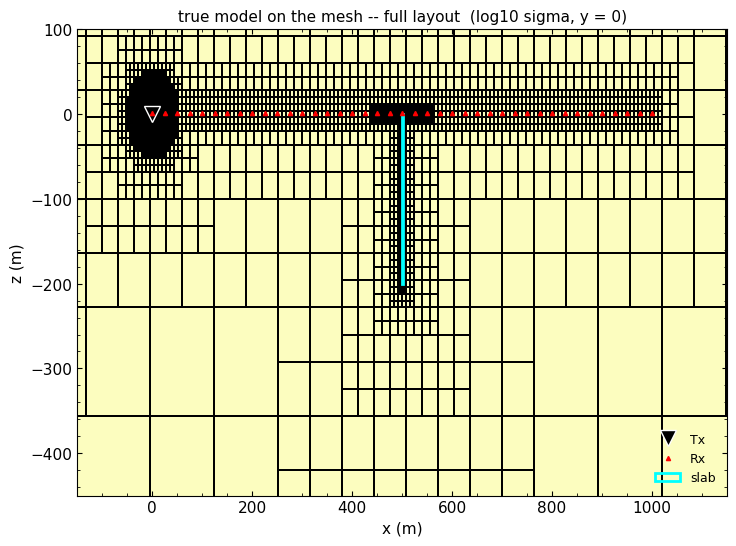

In [21]:
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 11})
sigma_true = models["conductive"]
ind_y0 = int(np.argmin(np.abs(mesh.cell_centers_y - 0.0)))
# overlap-weighted conductance; see build_models)
sxmin, sxmax = sheet_cx - slab_t/2, sheet_cx + slab_t/2
szmin, szmax = sheet_cz - sheet_dip_extent/2, sheet_cz + sheet_dip_extent/2
fig, ax = plt.subplots(figsize=(7.5, 5.6))
mesh.plot_slice(np.log10(sigma_true), normal="Y", ind=ind_y0, ax=ax, grid=True,
                pcolor_opts={"cmap": "magma_r"},
                grid_opts={"color": "k", "alpha": 0.25, "lw": 0.3})
ax.plot(src_loc[0], src_loc[2], "kv", ms=12, mec="white", label="Tx")
ax.plot(rx_loc[::5, 0], rx_loc[::5, 2], "r^", ms=3, label="Rx")
ax.add_patch(plt.Rectangle((sxmin, szmin), sxmax - sxmin, szmax - szmin,
                           fill=False, edgecolor="cyan", lw=2, label="slab"))
ax.set_xlim(-150, 1150); ax.set_ylim(-450, 100)
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
ax.set_title("true model on the mesh -- full layout  (log10 sigma, y = 0)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

In [22]:
SUBPROCESS_SOLVES = True

WORKER = r'''import json, sys, time, warnings
import numpy as np
from discretize import TreeMesh
try:
    from simpeg import maps
    from simpeg.electromagnetics import frequency_domain as fdem
except ImportError:
    from SimPEG import maps
    from SimPEG.electromagnetics import frequency_domain as fdem
warnings.filterwarnings("ignore")

cfg = json.load(open("solver_cfg.json"))
dh = cfg["dh"]
mesh = TreeMesh([[(dh, cfg["n_base"])]]*3, origin=np.array(cfg["origin"]),
                diagonal_balance=True)
lv = lambda cs: mesh.max_level - int(round(np.log2(cs/dh)))
for r, cs in cfg["balls"]:
    mesh.refine_ball(np.array(cfg["src"]), r, lv(cs), finalize=False)
for lo, hi, cs in cfg["boxes"]:
    mesh.refine_box(np.array(lo), np.array(hi), lv(cs), finalize=False)
mesh.finalize()
assert mesh.nC == cfg["nC"] and mesh.n_faces == cfg["n_faces"], \
    f"worker mesh mismatch: {mesh.nC}/{mesh.n_faces} vs {cfg['nC']}/{cfg['n_faces']}"

rx_loc = np.array(cfg["rx_loc"])
rx = [fdem.receivers.PointMagneticFluxDensity(rx_loc, orientation=o, component=c)
      for o in "xyz" for c in ("real", "imag")]
src = fdem.sources.MagDipole(rx, frequency=cfg["frequency"],
                             location=np.array(cfg["src"]),
                             orientation="z", moment=cfg["moment"])
survey = fdem.Survey([src])

if cfg["solver"] == "SolverLU":
    try:
        from simpeg.utils.solver_utils import SolverLU as S
    except ImportError:
        from SimPEG import SolverLU as S
else:
    import pymatsolver
    S = getattr(pymatsolver, cfg["solver"])

name = sys.argv[1]
model = np.load(f"model_{name}.npy")
sim = fdem.simulation.Simulation3DMagneticFluxDensity(
    mesh, survey=survey, sigmaMap=maps.IdentityMap(mesh), solver=S)
t0 = time.time()
np.save(f"data_{name}.npy", sim.dpred(model))
print(f"{time.time()-t0:.1f}", flush=True)
'''

scenarios = ("background", "zerocontrast", "conductive")
H_num = {}
if SUBPROCESS_SOLVES:
    import json as _json
    import subprocess
    import sys as _sys
    with open("solve_worker.py", "w") as f:
        f.write(WORKER)
    s = MESH_SETTINGS[RESOLUTION]
    _json.dump(dict(dh=s["dh"], n_base=s["n_base"],
                    origin=[float(v) for v in mesh.origin],
                    balls=[list(map(float, b)) for b in s["balls"]],
                    boxes=[[list(map(float, lo)), list(map(float, hi)), float(cs)]
                           for lo, hi, cs in s["boxes"]],
                    src=[float(v) for v in src_loc], moment=float(moment),
                    frequency=float(frequency),
                    rx_loc=[[float(v) for v in row] for row in rx_loc],
                    nC=int(mesh.nC), n_faces=int(mesh.n_faces),
                    solver=solver_name.split(".")[-1].split(" ")[0]),
               open("solver_cfg.json", "w"))
    for name in scenarios:
        np.save(f"model_{name}.npy", models[name])
    del models, mesh, survey
    gc.collect()
    for name in scenarios:
        t0 = time.time()
        r = subprocess.run([_sys.executable, "solve_worker.py", name],
                           capture_output=True, text=True)
        assert r.returncode == 0, f"worker failed for {name}:\n{r.stderr[-2000:]}"
        print(f"scenario '{name}': solved in {float(r.stdout.strip()):6.1f} s "
              f"(subprocess wall {time.time()-t0:.1f} s)")
        H_num[name] = to_H(np.load(f"data_{name}.npy"))
else:
    for name in scenarios:
        sim = fdem.simulation.Simulation3DMagneticFluxDensity(
            mesh, survey=survey, sigmaMap=maps.IdentityMap(mesh), solver=Solver)
        t0 = time.time()
        d = sim.dpred(models[name])
        print(f"scenario '{name}': solved in {time.time()-t0:6.1f} s")
        H_num[name] = to_H(d)
        del sim
        gc.collect()

# secondary = total(k) - total(background), on the same mesh
Hbg = H_num["background"]
H_sec = {k: tuple(t - b for t, b in zip(H_num[k], Hbg))
         for k in ("conductive", "zerocontrast")}
H_sec["background"] = tuple(np.zeros(n_rx, complex) for _ in range(3))

# reported total = analytic primary + numerical secondary (IE-style composition)
H_pri = analytic_H_zdipole(rx_loc, frequency)
H_tot = {k: tuple(p + s for p, s in zip(H_pri, H_sec[k])) for k in H_sec}
print("secondary and total fields assembled for all three scenarios")

scenario 'background': solved in   47.1 s (subprocess wall 55.1 s)
scenario 'zerocontrast': solved in   48.7 s (subprocess wall 58.7 s)
scenario 'conductive': solved in   48.1 s (subprocess wall 55.5 s)
secondary and total fields assembled for all three scenarios


Checks: background vs analytic (trusted window), Hy symmetry, secondary scales vs the 10 Hz IE reference, the Hz crossover by linear interpolation of ...

In [23]:
Hana = H_pri
Hnum = H_num["background"]
ratio = np.full(n_rx, np.nan + 1j*np.nan, complex)
nz = np.abs(Hana[2]) > 0
ratio[nz] = Hnum[2][nz] / Hana[2][nz]
amp, dph = np.abs(ratio), np.degrees(np.angle(ratio))
for lo, hi in [(5, 20), (20, 50), (50, 100), (100, 200), (200, 500), (500, 1000)]:
    sel = (rx_x >= lo) & (rx_x <= hi) & nz
    q = ratio[sel]
    print(f"x {lo:5.0f} - {hi:5.0f} m: median |ratio| {np.median(np.abs(q)):12.4e},  "
          f"median phase err {np.median(np.degrees(np.angle(q))):+8.2f} deg")

amp_med = np.array([np.nanmedian(amp[max(0, i-2):i+3]) for i in range(n_rx)])
dph_med = np.array([np.nanmedian(dph[max(0, i-2):i+3]) for i in range(n_rx)])
ok = nz & (np.abs(amp_med - 1.0) < 0.12) & (np.abs(dph_med) < 15.0)
x_edge = 1000.0
for i in range(n_rx):
    if rx_x[i] < 20.0:
        continue
    if not ok[i]:
        x_edge = rx_x[i-1]
        break
print(f"--> trusted window (rolling-median |amp-1| < 12%, |phase| < 15 deg): "
      f"x <= {x_edge:.0f} m  ({x_edge/skin_depth:.2f} skin depths)")
print("    note: the x = 5-20 m raw ratio is expected to be poor -- those receivers sit")
print("    inside the (deliberately) coarse source cells; it does not reach the reported")
print("    outputs (analytic-primary composition + differencing).")

print()
for name in ("background", "zerocontrast", "conductive"):
    Hy = H_num[name][1]
    Hz0 = np.abs(H_num[name][2][0])
    print(f"symmetry, {name:13s}: max |Hy| = {np.abs(Hy).max():.3e} A/m "
          f"(= {np.abs(Hy).max()/Hz0:.1e} of |Hz| at the first receiver)")

print()
sec_c = np.max([np.abs(v).max() for v in H_sec["conductive"]])
sec_z = np.max([np.abs(v).max() for v in H_sec["zerocontrast"]])
print(f"max |secondary|, conductive target : {sec_c:.3e} A/m   "
      f"(IE reference {IE_PEAK_SEC:.4e};  ratio {sec_c/IE_PEAK_SEC:.2f} -- "
      f"a near-field value 0.75 m from the sheet edge; see the overlay cell)")
print(f"max |secondary|, zero contrast     : {sec_z:.3e} A/m   "
      f"(IE quadrature floor {IE_ZC_FLOOR:.1e}; different noise mechanisms, "
      f"both tiny vs the signal -- no agreement expected)")
print(f"null-test suppression factor       : {sec_c/max(sec_z, 1e-300):.2e}")

Sz = H_sec["conductive"][2].real
s = np.sign(Sz)
idx = np.where((np.diff(s) != 0) & (np.abs(rx_x[:-1] - 500.0) < 150.0))[0]
if idx.size:
    xc = [rx_x[i] - Sz[i]*(rx_x[i+1] - rx_x[i])/(Sz[i+1] - Sz[i]) for i in idx]
    x_cross = min(xc, key=lambda c: abs(c - IE_CROSSOVER))
    print(f"Hz secondary sign crossover        : x = {x_cross:.1f} m "
          f"(linear-interpolated; IE reference {IE_CROSSOVER:.0f} m)")
else:
    print("no Sec_Z_Re crossover found within 150 m of the sheet plane")

i500 = int(np.argmin(np.abs(rx_x - 500.0)))
sx = H_sec["conductive"][0][i500]
print(f"|Re/Im| of Sec_X at x = 500 m      : {abs(sx.real/sx.imag):.3f} "
      f"(IE: {IE_RE_IM:.3f}; at 10 Hz the secondary is in-phase dominant -- "
      f"the Re part is the dominant comparison channel)")

x     5 -    20 m: median |ratio|   1.0955e+00,  median phase err    -0.00 deg
x    20 -    50 m: median |ratio|   1.0233e+00,  median phase err    +0.00 deg
x    50 -   100 m: median |ratio|   1.0098e+00,  median phase err    +0.01 deg
x   100 -   200 m: median |ratio|   1.0029e+00,  median phase err    +0.02 deg
x   200 -   500 m: median |ratio|   1.0023e+00,  median phase err    +0.09 deg
x   500 -  1000 m: median |ratio|   1.0018e+00,  median phase err    +0.15 deg
--> trusted window (rolling-median |amp-1| < 12%, |phase| < 15 deg): x <= 1000 m  (1.99 skin depths)
    note: the x = 5-20 m raw ratio is expected to be poor -- those receivers sit
    inside the (deliberately) coarse source cells; it does not reach the reported
    outputs (analytic-primary composition + differencing).

symmetry, background   : max |Hy| = 1.575e-19 A/m (= 6.0e-17 of |Hz| at the first receiver)
symmetry, zerocontrast : max |Hy| = 1.575e-19 A/m (= 6.0e-17 of |Hz| at the first receiver)
symmetry, conducti

## SimPEG vs IE — full-curve overlay (runs when `h-field-IE-*-10Hz.dat` are present)

Flank statistics (|x − 500| > 20 m) use the part-agnostic **complex relative difference** |SimPEG − IE| / |IE| on samples above 5 ...

scenario 1 Sec_X: flank rel diff median  29.9% (max 33%) | peak-zone amplitude ratio simpeg/ie = 0.61
scenario 1 Sec_Z: flank rel diff median   8.2% (max 24%) | peak-zone amplitude ratio simpeg/ie = 0.72


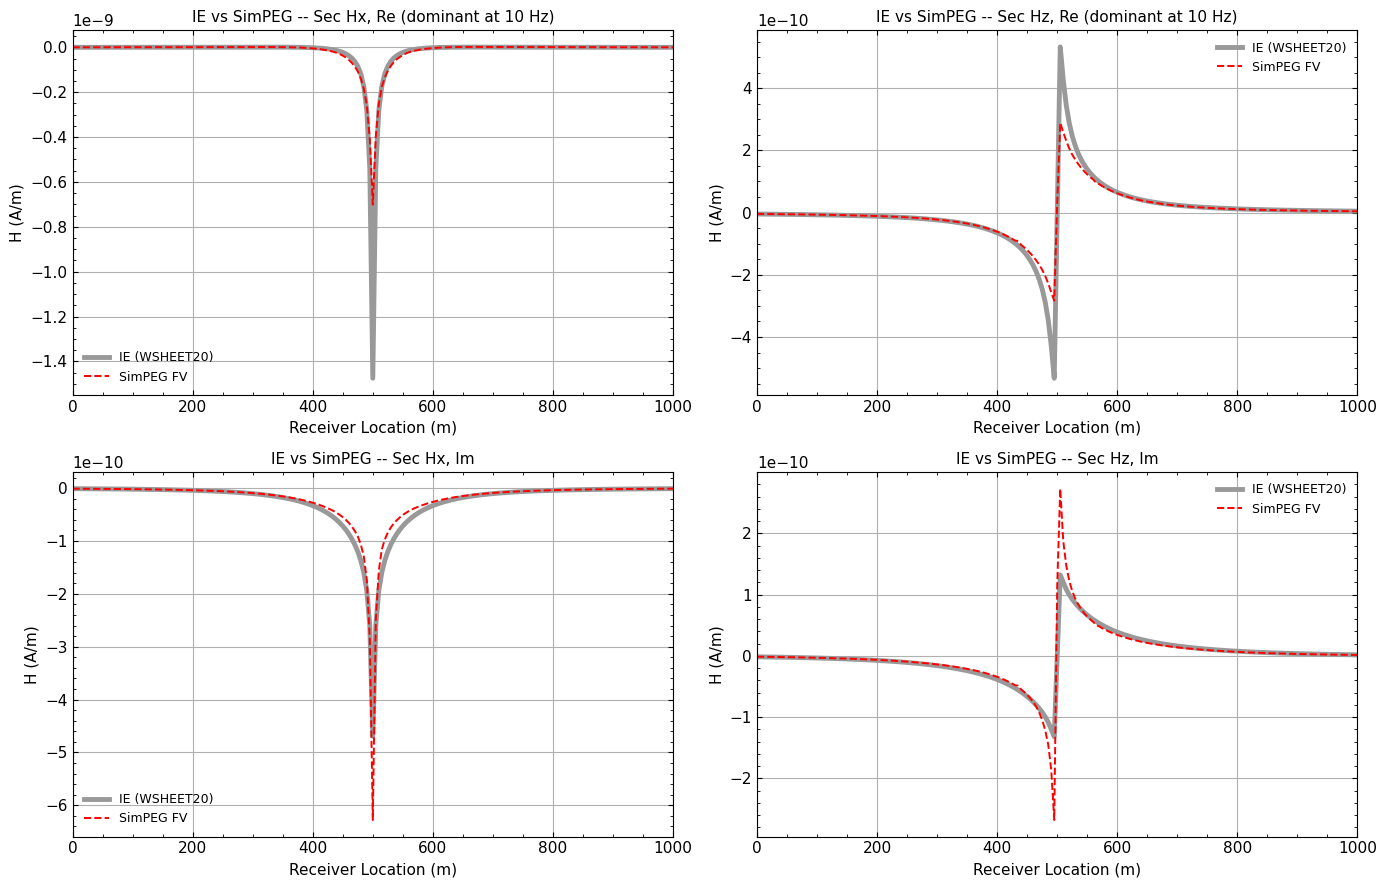

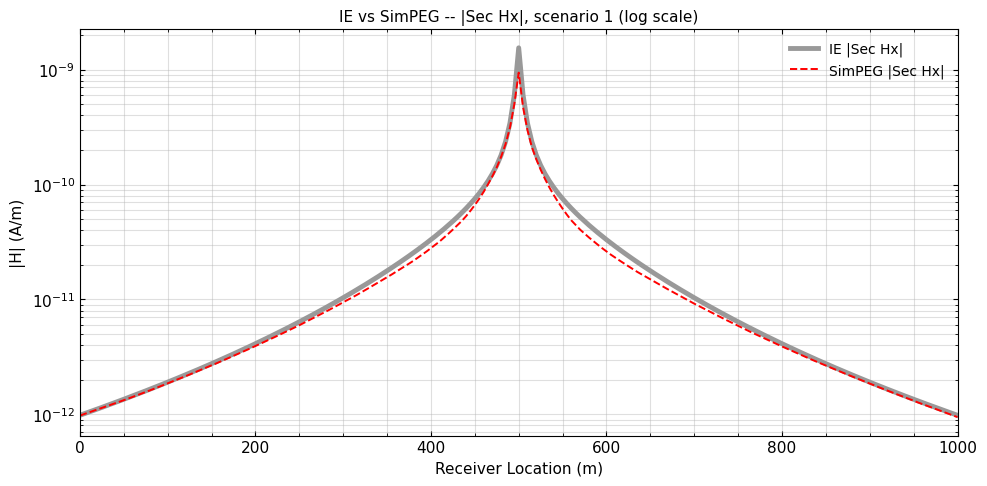

scenario 2: max |secondary|  IE 1.650e-20  vs  SimPEG 1.453e-20 A/m (different noise mechanisms; no agreement expected or required)
scenario 3: max |secondary|  IE 0.000e+00  vs  SimPEG 0.000e+00 A/m (different noise mechanisms; no agreement expected or required)


In [24]:
COLS = ['X', 'Y', 'Z',
        'Sec_X_Re', 'Sec_X_Im', 'Tot_X_Re', 'Tot_X_Im',
        'Sec_Y_Re', 'Sec_Y_Im', 'Tot_Y_Re', 'Tot_Y_Im',
        'Sec_Z_Re', 'Sec_Z_Im', 'Tot_Z_Re', 'Tot_Z_Im']

for scen, label in [('conductive', 'scenario 1'), ('zerocontrast', 'scenario 2'),
                    ('background', 'scenario 3')]:
    iefile = f'h-field-IE-{scen}-10Hz.dat'
    if not os.path.exists(iefile):
        print(f'{iefile} not found - skipping {label}')
        continue
    ie = pd.read_csv(iefile, sep=r'\s+', skiprows=1, names=COLS)
    ie_sec = {c: ie[f'Sec_{c}_Re'].to_numpy() + 1j*ie[f'Sec_{c}_Im'].to_numpy()
              for c in 'XYZ'}
    sp_sec = dict(zip('XYZ', H_sec[scen]))

    if scen == 'conductive':
        for c in ('X', 'Z'):
            i_, s_ = ie_sec[c], sp_sec[c]
            sig = np.abs(i_) > 0.05*np.abs(i_).max()
            flank = sig & (np.abs(rx_x - 500.0) > 20.0)
            peakz = sig & (np.abs(rx_x - 500.0) <= 20.0)
            r_f = np.abs(s_[flank] - i_[flank])/np.abs(i_[flank])
            print(f"{label} Sec_{c}: flank rel diff median {100*np.median(r_f):5.1f}% "
                  f"(max {100*r_f.max():.0f}%) | "
                  f"peak-zone amplitude ratio simpeg/ie = "
                  f"{np.abs(s_[peakz]).max()/np.abs(i_[peakz]).max():.2f}")
        fig, axes = plt.subplots(2, 2, figsize=(14, 9))
        for row, (part, pname) in enumerate([(np.real, 'Re (dominant at 10 Hz)'),
                                             (np.imag, 'Im')]):
            for col, c in enumerate(('X', 'Z')):
                ax = axes[row, col]
                ax.plot(rx_x, part(ie_sec[c]), '-', color='0.6', lw=3.5,
                        label='IE (WSHEET20)')
                ax.plot(rx_x, part(sp_sec[c]), 'r--', lw=1.4, label='SimPEG FV')
                ax.set_xlim(0, 1000)
                ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
                ax.set_xlabel('Receiver Location (m)'); ax.set_ylabel('H (A/m)')
                ax.set_title(f'IE vs SimPEG -- Sec H{c.lower()}, {pname}')
                ax.grid(True); ax.legend(fontsize=9)
        plt.tight_layout(); plt.show()

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.semilogy(rx_x, np.abs(ie_sec['X']), '-', color='0.6', lw=3.5,
                    label='IE |Sec Hx|')
        ax.semilogy(rx_x, np.abs(sp_sec['X']), 'r--', lw=1.4, label='SimPEG |Sec Hx|')
        ax.set_xlim(0, 1000)
        ax.set_xlabel('Receiver Location (m)'); ax.set_ylabel('|H| (A/m)')
        ax.set_title(f'IE vs SimPEG -- |Sec Hx|, {label} (log scale)')
        ax.grid(True, which='both', alpha=0.4); ax.legend()
        plt.tight_layout(); plt.show()
    else:
        ie_max = max(np.abs(v).max() for v in ie_sec.values())
        sp_max = max(np.abs(v).max() for v in sp_sec.values())
        print(f"{label}: max |secondary|  IE {ie_max:.3e}  vs  SimPEG {sp_max:.3e} A/m "
              f"(different noise mechanisms; no agreement expected or required)")

In [10]:
def write_hfield(scenario, fname):
    S, T = H_sec[scenario], H_tot[scenario]
    with open(fname, "w") as f:
        f.write("    X       Y       Z    "
                "  Sec_X_Re      Sec_X_Im      Tot_X_Re      Tot_X_Im    "
                "  Sec_Y_Re      Sec_Y_Im      Tot_Y_Re      Tot_Y_Im    "
                "  Sec_Z_Re      Sec_Z_Im      Tot_Z_Re      Tot_Z_Im\n")
        for i in range(n_rx):
            f.write(f"{rx_x[i]:8.2f} {0.0:7.2f} {rx_z:7.2f}")
            for comp in range(3):
                f.write(f" {S[comp][i].real:13.5e} {S[comp][i].imag:13.5e}"
                        f" {T[comp][i].real:13.5e} {T[comp][i].imag:13.5e}")
            f.write("\n")
    print("wrote", fname)

for scen in ("conductive", "zerocontrast", "background"):
    write_hfield(scen, f"h-field-simpeg-{scen}-10Hz.dat")
print("\nAll three SimPEG output files written.")

wrote h-field-simpeg-conductive-10Hz.dat
wrote h-field-simpeg-zerocontrast-10Hz.dat
wrote h-field-simpeg-background-10Hz.dat

All three SimPEG output files written.


Plots in the project journal style ($H_x$ black solid, $H_y$ blue dashed, $H_z$ red dash-dot): total field (symlog, linthresh 10⁻¹², matching the IE 1 ...

In [11]:
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'mathtext.fontset': 'dejavusans',
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

_COMP = (('$H_x$', 'k',        '-'),
         ('$H_y$', '#1565C0', '--'),
         ('$H_z$', '#C62828', '-.'))

def _finish(ax, title):
    ax.set_xlim(0, 1000)
    ax.axvline(500.0, color='0.45', lw=0.7, ls=(0, (4, 3)), zorder=1)
    ax.text(500.0, 1.015, 'sheet', transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', fontsize=8.5, color='0.35')
    ax.set_xlabel('Receiver position $x$ (m)')
    ax.set_title(title, pad=16)
    ax.grid(True, which='major', lw=0.4, alpha=0.35)
    ax.legend(loc='upper right', handlelength=2.4)

def plot_total(scen, title, save=None):
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for comp, (lab, col, ls) in zip(H_tot[scen], _COMP):
        ax.plot(rx_x, comp.real, lw=1.6, color=col, ls=ls, label=lab)
    ax.set_yscale('symlog', linthresh=1e-12)
    ax.set_ylabel('Magnetic field, Re $H$ (A m$^{-1}$)')
    _finish(ax, f'Total field — {title}')
    fig.tight_layout()
    if save:
        fig.savefig(save)
    plt.show()

def plot_secondary(scen, title, part=np.real, part_name='Re', save=None):
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for comp, (lab, col, ls) in zip(H_sec[scen], _COMP):
        ax.plot(rx_x, part(comp), lw=1.6, color=col, ls=ls, label=lab)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(9)
    ax.set_ylabel(f'Magnetic field, {part_name} $H$ (A m$^{{-1}}$)')
    _finish(ax, f'Secondary field ({part_name}) — {title}')
    fig.tight_layout()
    if save:
        fig.savefig(save)
    plt.show()

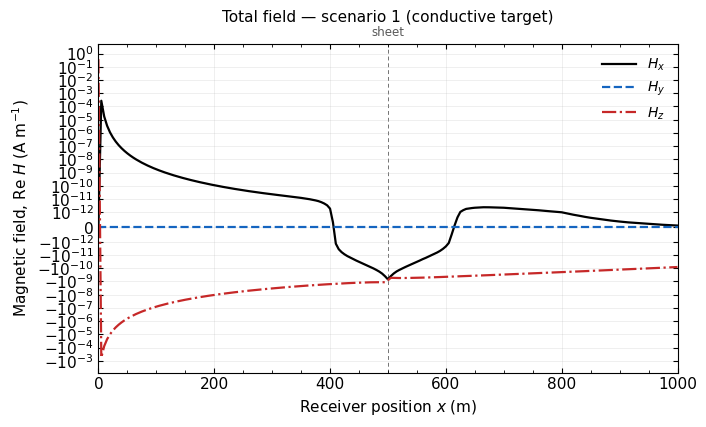

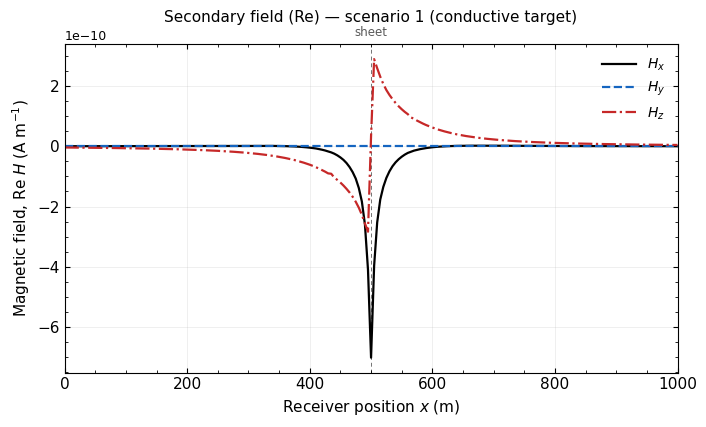

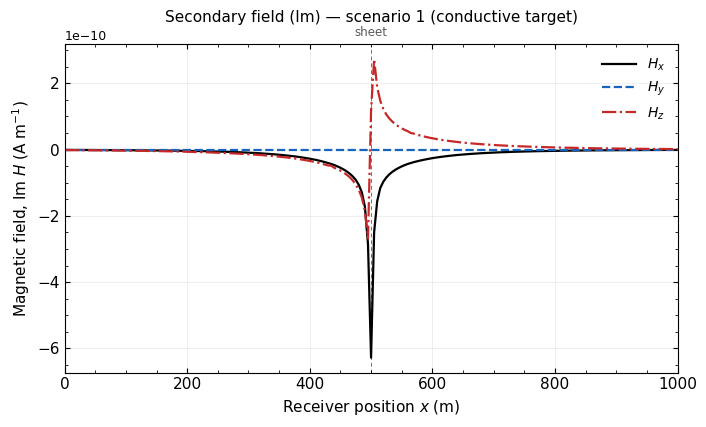

In [12]:
plot_total('conductive', 'scenario 1 (conductive target)')
plot_secondary('conductive', 'scenario 1 (conductive target)')
plot_secondary('conductive', 'scenario 1 (conductive target)',
               part=np.imag, part_name='Im')

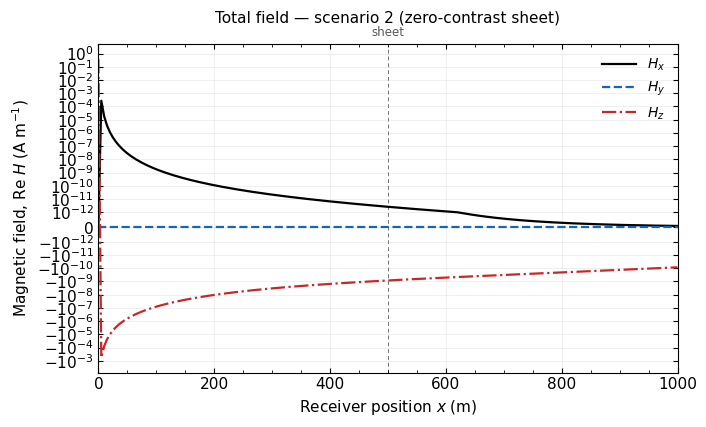

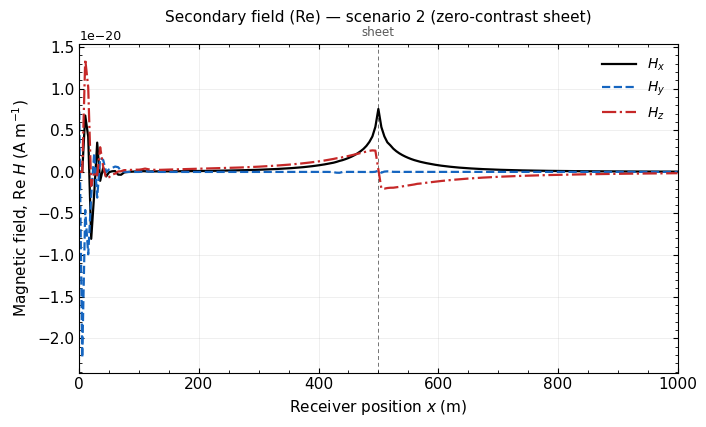

In [13]:
plot_total('zerocontrast', 'scenario 2 (zero-contrast sheet)')
plot_secondary('zerocontrast', 'scenario 2 (zero-contrast sheet)')

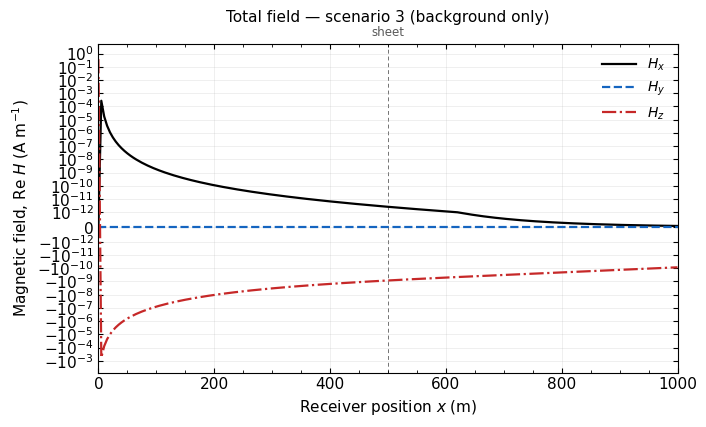

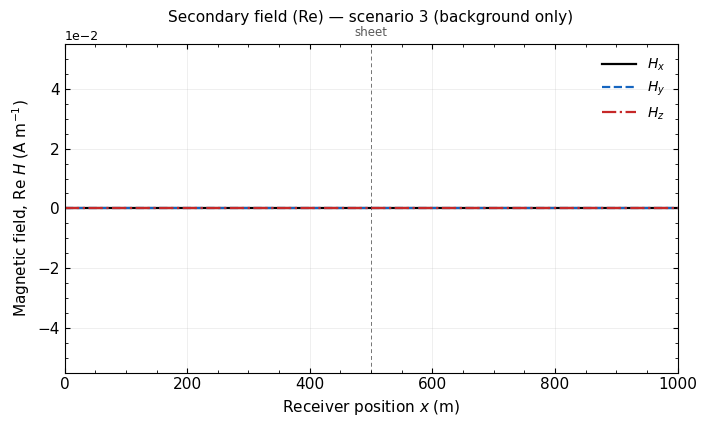

In [14]:
plot_total('background', 'scenario 3 (background only)')
plot_secondary('background', 'scenario 3 (background only)')